# Model B — Probability of 30-day activation

**Hackathon Ada Tech · Track C · Team 1 — From signup to first use**

---

## What this notebook does, in plain language

We want more customers to make their first transaction within 30 days of signing up. That number — the **North Star** — is currently **19.24%**.

It breaks into two multiplied parts:

```
19.24%  =  44.31%              x   43.43%
North     complete onboarding      activate, given they completed
Star
```

This notebook attacks the **second part only**. It looks at the 115,192 people who finished opening their account and asks: *for each one, what is the probability they will actually use it in the first 30 days?*

Once we have that probability per customer, we split them into three groups and give each group a different treatment. That is the product recommendation.

## Why we need a model at all

Sending a reminder push costs almost nothing, so we can send it to everybody — no model needed for that decision.

But a **discount or interest-free-months offer costs real money**. If we give it to someone who was going to activate anyway, we spent money and gained nothing.

The model exists to answer one question: **who should we pay to convince?**

That is also the brief's second guardrail — *do not harm customers who already had high propensity to convert.* We satisfy it by not spending on them.

## Important honesty note — read this before writing the pitch

This model predicts **who will activate**. It does *not* predict **who will activate because we contacted them**. Those are different things, and measuring the second one requires an experiment (some customers treated, some not) that does not exist in this dataset.

So: the model tells us where to *aim*. It does not prove the intervention works. The PRD must include a control group so the next cycle can actually measure it.

Claiming otherwise in front of the judges is the fastest way to lose the argument.

---

## Notebook map

| Section | What happens |
| --- | --- |
| 1 | Load the three tables |
| 2 | Data quality: nulls, scale, censoring |
| 3 | **Leakage check** — the trap this exercise is built around |
| 4 | Turn 1.4M event rows into one row per customer |
| 5 | Build features |
| 6 | Split train/test by time |
| 7 | Baselines (what we must beat) |
| 8 | Train the models |
| 9 | **AUC, PR-AUC, calibration** — required by the brief |
| 10 | Decile table: where do we cut the list |
| 11 | Three segments + cost sizing |
| 12 | What the model learned |
| 13 | Score everyone and save |


## 0. Configuration

Everything you might want to change lives here. Nothing below this cell needs editing to get a first run.


In [0]:
# Where the data lives (Unity Catalog Volume)
DATA_PATH = "/Volumes/usr/rodolfolopez/hackathon"

# Where to save results. Set WRITE_TABLES = True when you are happy with the run.
OUTPUT_SCHEMA = "usr.rodolfolopez"
WRITE_TABLES  = False

# Reproducibility
RANDOM_STATE = 20260806

# The last 20% of the signup window becomes the test set (see section 6)
TEST_FRACTION_BY_TIME = 0.20

# Real-world context for scaling (see section 2b)
REAL_DAILY_SIGNUPS = 12_000

print("config loaded")

config loaded


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

# display() exists in Databricks. This fallback lets the notebook run elsewhere.
try:
    display
except NameError:
    from IPython.display import display

print("imports ok")

imports ok


## 1. Load the three tables

Three files, joined on `customer_id`:

* **`customers`** — one row per signup. Who they are: channel, device, app version, age, state.
* **`onboarding_events`** — one row per *attempt* at each funnel step. This is the messy one: 1.4M rows for only 260k people, because the selfie step allows retries.
* **`activation_labels`** — one row per signup. Did they finish onboarding, did they activate, how long did it take.


In [0]:
customers = spark.read.parquet(f"{DATA_PATH}/customers.parquet")
events    = spark.read.parquet(f"{DATA_PATH}/onboarding_events.parquet")
labels    = spark.read.parquet(f"{DATA_PATH}/activation_labels.parquet")

for name, df in [("customers", customers), ("onboarding_events", events), ("activation_labels", labels)]:
    n_rows = df.count()
    n_ids  = df.select("customer_id").distinct().count()
    print(f"{name:20s} {n_rows:>10,} rows   {n_ids:>10,} distinct customers")

customers               260,000 rows      260,000 distinct customers
onboarding_events     1,386,264 rows      260,000 distinct customers
activation_labels       260,000 rows      260,000 distinct customers


**Expected output** (validated against the files before this notebook was written):

```
customers               260,000 rows      260,000 distinct customers
onboarding_events     1,386,264 rows      260,000 distinct customers
activation_labels       260,000 rows      260,000 distinct customers
```

Notice the second line: **1.4M rows, 260k people.** This is the single most important fact about this dataset. Every count from now on must be `COUNT(DISTINCT customer_id)`, never `COUNT(*)`.


## 2. Data quality

### 2a. Where are the nulls?

The dataset README claims *two tables carry nulls by design*. We checked the actual files — that claim is wrong. Only `activation_labels` has nulls, and they are not missing data at all: they are the leakage columns (section 3).

Rule for this project: **trust the files, not the documentation.** When the two disagree, the data wins.


In [0]:
def null_profile(df, name):
    n = df.count()
    counts = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]) \
               .collect()[0].asDict()
    print(f"\n--- {name}  ({n:,} rows) ---")
    hits = {c: v for c, v in counts.items() if v}
    if not hits:
        print("  no nulls in any column")
    for c, v in hits.items():
        print(f"  {c:32s} {v:>9,}  ({v/n:6.2%})")

for df, nm in [(customers, "customers"), (events, "onboarding_events"), (labels, "activation_labels")]:
    null_profile(df, nm)


--- customers  (260,000 rows) ---
  no nulls in any column

--- onboarding_events  (1,386,264 rows) ---
  no nulls in any column

--- activation_labels  (260,000 rows) ---
  days_to_first_transaction          209,976  (80.76%)
  first_transaction_ts               209,976  (80.76%)


**Expected output:** `customers` and `onboarding_events` are completely clean — zero nulls in every column. `activation_labels` has 209,976 nulls in each of `days_to_first_transaction` and `first_transaction_ts`.

209,976 = 260,000 − 50,024 activated customers. That is not a coincidence, and section 3 explains why it matters enormously.

**For `docs/data-dictionary.md`:** no imputation decision is needed anywhere, because the only nulls in the dataset sit in two columns we are about to delete.


### 2b. Scale: this dataset is a sample, not the real inflow

Nu Mexico takes in roughly **12,000 signups per day**. This dataset holds 260,000 signups spread across its date range, which is a much lower daily rate. So every cost and impact number has to declare which scale it is on.

The rule for this project: **the pitch uses the real inflow.** One percentage point of North Star means something very different at 1,444/day than at 12,000/day.


In [0]:
span = customers.select(
    F.min("signup_ts").alias("min_ts"),
    F.max("signup_ts").alias("max_ts"),
    F.count("*").alias("n"),
).collect()[0]

span_days    = (span["max_ts"] - span["min_ts"]).total_seconds() / 86400
SAMPLE_DAILY = span["n"] / span_days
SCALE_RATIO  = REAL_DAILY_SIGNUPS / SAMPLE_DAILY

print(f"signup window     : {span['min_ts']}  ->  {span['max_ts']}")
print(f"window length     : {span_days:.1f} days")
print(f"sample daily rate : {SAMPLE_DAILY:,.0f} signups/day")
print(f"real daily inflow : {REAL_DAILY_SIGNUPS:,} signups/day")
print(f"")
print(f"SCALE_RATIO       : {SCALE_RATIO:.2f}x")
print(f"  -> multiply any per-day figure from this sample by {SCALE_RATIO:.2f} to reach real scale")

signup window     : 2026-02-01 00:00:59  ->  2026-07-31 23:56:56
window length     : 181.0 days
sample daily rate : 1,436 signups/day
real daily inflow : 12,000 signups/day

SCALE_RATIO       : 8.35x
  -> multiply any per-day figure from this sample by 8.35 to reach real scale


**Expected:** window is 2026-02-01 to 2026-07-31 (180 days), sample rate **1,444 signups/day**, so `SCALE_RATIO` ≈ **8.31x**.


### 2c. Censoring check

A "did they activate within 30 days" label cannot be complete for someone who signed up 5 days before the data was cut — there has not been enough time to observe them.

If that were happening here, the most recent signups would show an artificially low activation rate and we would have to throw them out.

So we check before assuming.


In [0]:
cens = (customers.select("customer_id", "signup_ts")
        .join(labels.select("customer_id", "activated_30d", "completed_onboarding"), "customer_id")
        .withColumn("signup_month", F.date_trunc("MONTH", "signup_ts"))
        .groupBy("signup_month")
        .agg(F.count("*").alias("signups"),
             F.round(F.avg(F.col("completed_onboarding").cast("double")), 4).alias("completion_rate"),
             F.round(F.avg(F.col("activated_30d").cast("double")), 4).alias("activation_rate"))
        .orderBy("signup_month"))

display(cens)

signup_month,signups,completion_rate,activation_rate
2026-02-01T00:00:00Z,40145,0.4467,0.1937
2026-03-01T00:00:00Z,44683,0.4392,0.1909
2026-04-01T00:00:00Z,43125,0.4437,0.1938
2026-05-01T00:00:00Z,44710,0.4422,0.1908
2026-06-01T00:00:00Z,42915,0.4455,0.196
2026-07-01T00:00:00Z,44422,0.4413,0.1895


**Expected:** the activation rate is flat month to month — February 19.37%, July 18.96%. The last cohort is not depressed, so **there is no censoring** and we keep every row.

**Decision-log entry:** *No right-censoring detected. Monthly activation rate is stable across the full window (19.37% in the first month vs 18.96% in the last), so signups near the end of the window are not excluded.*

A side effect worth knowing: since nothing changes over time, `signup_ts` carries no predictive signal. We still split by time in section 6, because that is the methodologically correct thing to do, but do not expect it to change results much.


## 3. Leakage check

**This is the trap the whole exercise is built around, and the brief explicitly requires us to verify it.**

*Leakage* means using a column that secretly contains the answer. A model trained on leaked data gets a near-perfect score and is completely useless in production, because at the moment you actually need a prediction, that column does not exist yet.

There are three levels of it here.

### Level 1 — Total leakage

`days_to_first_transaction` and `first_transaction_ts` are filled in **only** for people who activated. If the column has a value, the answer is yes. If it is null, the answer is no. A model using them would score 100% and predict nothing.

**These two columns are deleted. They never touch the model.**

### Level 2 — Conditional leakage

`completed_onboarding` and `steps_completed` partly determine the answer, because activation is only even possible for people who completed onboarding.

We use them **once**, to select who is in the population. After that they are gone. Inside our population they are constants anyway — everyone has `completed_onboarding = True` and `steps_completed = 7`.

### Level 3 — Per-stage leakage

Not relevant to this notebook, but it matters for Model A: a model predicting drop-off at step 4 cannot use anything that happened at steps 5, 6 or 7.

Below we verify levels 1 and 2 with hard assertions rather than trusting the description.


In [0]:
chk = labels.select(
    F.count("*").alias("n"),
    F.sum(F.col("activated_30d").cast("int")).alias("n_activated"),
    F.sum(F.col("days_to_first_transaction").isNull().cast("int")).alias("null_days"),
    # violations of "null if and only if not activated"
    F.sum((F.col("activated_30d") & F.col("days_to_first_transaction").isNull()).cast("int")).alias("v1"),
    F.sum(((~F.col("activated_30d")) & F.col("days_to_first_transaction").isNotNull()).cast("int")).alias("v2"),
    F.sum((F.col("activated_30d") & (~F.col("completed_onboarding"))).cast("int")).alias("v3"),
    F.sum((F.col("completed_onboarding") & (F.col("steps_completed") != 7)).cast("int")).alias("v4"),
    F.sum(((~F.col("completed_onboarding")) & (F.col("steps_completed") == 7)).cast("int")).alias("v5"),
).collect()[0]

print(f"total customers                          : {chk['n']:,}")
print(f"activated                                : {chk['n_activated']:,}")
print(f"nulls in days_to_first_transaction       : {chk['null_days']:,}")
print(f"  n - n_activated                        : {chk['n'] - chk['n_activated']:,}   <- must match")
print()
print("LEAKAGE ASSERTIONS")
print(f"  activated but null timestamp           : {chk['v1']}")
print(f"  not activated but has timestamp        : {chk['v2']}")
print(f"  activated without completing onboarding: {chk['v3']}")
print(f"  completed but steps_completed != 7     : {chk['v4']}")
print(f"  steps_completed == 7 but not completed : {chk['v5']}")

assert chk["v1"] == 0 and chk["v2"] == 0, "leakage columns behave unexpectedly - investigate"
assert chk["v3"] == 0, "someone activated without completing onboarding - population filter is wrong"
assert chk["v4"] == 0 and chk["v5"] == 0, "completed_onboarding is not equivalent to steps_completed == 7"

print()
print("CONFIRMED: days_to_first_transaction / first_transaction_ts are null")
print("           if and only if activated_30d is false. Both are excluded.")
print("CONFIRMED: completed_onboarding is identical to steps_completed == 7.")
print("           They are one fact, not two signals. Used as a filter only.")

total customers                          : 260,000
activated                                : 50,024
nulls in days_to_first_transaction       : 209,976
  n - n_activated                        : 209,976   <- must match

LEAKAGE ASSERTIONS
  activated but null timestamp           : 0
  not activated but has timestamp        : 0
  activated without completing onboarding: 0
  completed but steps_completed != 7     : 0
  steps_completed == 7 but not completed : 0

CONFIRMED: days_to_first_transaction / first_transaction_ts are null
           if and only if activated_30d is false. Both are excluded.
CONFIRMED: completed_onboarding is identical to steps_completed == 7.
           They are one fact, not two signals. Used as a filter only.


**Expected:** all five violation counts are exactly 0, and 209,976 = 260,000 − 50,024.

**Decision-log entry:** *Target leakage verified empirically. `days_to_first_transaction` and `first_transaction_ts` are null if and only if `activated_30d` is false (0 violations in 260,000 rows); both are dropped before any modelling. `completed_onboarding` and `steps_completed == 7` were confirmed to be the same fact (0 discrepancies) and are used as a population filter, never as features.*


In [0]:
# Drop the level-1 leakage columns immediately, so they cannot be used by accident.
LEAKAGE_TOTAL = ["days_to_first_transaction", "first_transaction_ts"]
labels_clean = labels.drop(*LEAKAGE_TOTAL)
print("dropped:", LEAKAGE_TOTAL)
print("remaining label columns:", labels_clean.columns)

dropped: ['days_to_first_transaction', 'first_transaction_ts']
remaining label columns: ['customer_id', 'completed_onboarding', 'activated_30d', 'steps_completed']


## 4. Turning 1.4M event rows into one row per customer

The events table has one row per **attempt**, not per person. The `selfie_liveness` step lets people retry, so someone who struggled three times appears three times.

If we joined this table directly to `customers`, those strugglers would be counted three times each — and strugglers are exactly the population we care about. The model would be quietly biased toward them.

**So we aggregate first, join second. Always.**

### Two details that are easy to get wrong

**`ms_on_step` is per attempt, not per step.** To get the total time someone spent on the selfie step, you must **SUM** across their attempts. Using MAX or AVG understates precisely the people who had the hardest time.

**`status` has three values, not two.** `retry` marks an intermediate attempt; the final attempt of each step is either `completed` or `abandoned`. Someone who gave up has exactly one `abandoned` row, and it tells you where they quit.


In [0]:
# --- total time per customer per step: SUM across attempts, then pivot wide ---
ms_wide = (events.groupBy("customer_id")
           .pivot("step_number", [1, 2, 3, 4, 5, 6, 7])
           .agg(F.sum("ms_on_step")))
ms_wide = ms_wide.select("customer_id",
                         *[F.col(str(s)).alias(f"total_ms_step_{s}") for s in range(1, 8)])

# --- number of attempts per customer per step ---
att_wide = (events.groupBy("customer_id")
            .pivot("step_number", [1, 2, 3, 4, 5, 6, 7])
            .agg(F.max("attempt_no")))
att_wide = att_wide.select("customer_id",
                           *[F.col(str(s)).alias(f"attempts_step_{s}") for s in range(1, 8)])

# --- whole-journey rollups ---
journey = (events.groupBy("customer_id")
           .agg(F.sum("ms_on_step").alias("total_onboarding_ms"),
                F.max("step_number").alias("max_step_reached"),
                F.sum((F.col("status") == "retry").cast("int")).alias("n_retry_rows"),
                F.count("*").alias("n_event_rows"),
                F.min("event_ts").alias("first_event_ts"),
                F.max("event_ts").alias("last_event_ts")))

# --- the single abandoned row identifies where someone quit (null for completers) ---
drop_step = (events.filter(F.col("status") == "abandoned")
             .groupBy("customer_id")
             .agg(F.max("step_number").alias("abandoned_at_step")))

events_agg = (journey
              .join(ms_wide,   "customer_id", "left")
              .join(att_wide,  "customer_id", "left")
              .join(drop_step, "customer_id", "left"))

n_agg = events_agg.count()
print(f"events_agg: {n_agg:,} rows  (must equal 260,000 - one per customer)")
assert n_agg == 260_000, "aggregation did not collapse to one row per customer"
print("OK - grain is one row per customer")

events_agg: 260,000 rows  (must equal 260,000 - one per customer)
OK - grain is one row per customer


### A note on the nulls this creates

Someone who quit at step 3 has no rows for steps 4-7, so `total_ms_step_4` through `total_ms_step_7` come out null. **That is not missing data — it means "never got there."** The two are completely different and must not be imputed the same way.

For *this* notebook the distinction happens to be harmless, because every person in our population reached all seven steps. We assert that rather than assume it (next section). For Model A it matters a great deal.


## 5. Build the customer table and pick the population

Now we join everything into one wide table, then filter down to the people this model is about: **those who completed onboarding.**


In [0]:
wide = (customers
        .join(labels_clean, "customer_id", "inner")
        .join(events_agg,   "customer_id", "left"))

# THE POPULATION FILTER. completed_onboarding is used here and nowhere else.
model_b_sdf = wide.filter(F.col("completed_onboarding") == True)

n_all = wide.count()
n_pop = model_b_sdf.count()
rate_all = wide.select(F.avg(F.col("activated_30d").cast("double"))).collect()[0][0]
rate_pop = model_b_sdf.select(F.avg(F.col("activated_30d").cast("double"))).collect()[0][0]
completion_rate = n_pop / n_all

print(f"all signups          : {n_all:>8,}    activation {rate_all:7.3%}   <- NORTH STAR")
print(f"completed onboarding : {n_pop:>8,}    completion {completion_rate:7.3%}")
print(f"Model B population   : {n_pop:>8,}    activation {rate_pop:7.3%}   <- what we predict")
print()
print(f"decomposition check  : {completion_rate:.4%} x {rate_pop:.4%} = {completion_rate*rate_pop:.4%}")
print()
print(f"The PR-AUC baseline for this model is {rate_pop:.4f} (see section 9).")

# Confirm the structural-null claim from section 4
assert model_b_sdf.filter(F.col("max_step_reached") != 7).count() == 0
assert model_b_sdf.filter(F.col("steps_completed") != 7).count() == 0
assert model_b_sdf.filter(F.col("abandoned_at_step").isNotNull()).count() == 0
print("\nOK - every customer in the population reached all 7 steps.")
print("     No structural nulls survive the filter.")

all signups          :  260,000    activation 19.240%   <- NORTH STAR
completed onboarding :  115,192    completion 44.305%
Model B population   :  115,192    activation 43.427%   <- what we predict

decomposition check  : 44.3046% x 43.4266% = 19.2400%

The PR-AUC baseline for this model is 0.4343 (see section 9).

OK - every customer in the population reached all 7 steps.
     No structural nulls survive the filter.


**Expected:** 115,192 completers. Completion 44.305%, activation given completed 43.427%, and 44.305% × 43.427% = **19.24%**, matching the North Star exactly.

Note that our target is **43.4% positive**, not 19.2%. Inside this population the classes are close to balanced. PR-AUC is still required by the brief, but the "rare class" problem is mild here — a model must beat 0.434 PR-AUC to be doing anything at all.


## 6. Features

Two kinds of input:

1. **Who they are at signup** — channel, device, app version, age, state, whether they banked elsewhere before. Known before onboarding starts.
2. **How onboarding went** — how many selfie attempts, how long on the document upload, total time. Known by the time we need to score them, since we score *after* the account opens.

Both are legitimate here. (For Model A, only group 1 would be allowed.)


In [0]:
# app_version as an ordinal number, ordered by actual version, derived from data
versions = sorted([r[0] for r in customers.select("app_version").distinct().collect()],
                  key=lambda v: tuple(int(x) for x in v.split(".")))
print("app versions in order:", versions)

ver_map = F.create_map(*[x for v in versions for x in (F.lit(v), F.lit(versions.index(v)))])

feat_sdf = (model_b_sdf
    .withColumn("app_version_ordinal", ver_map[F.col("app_version")])
    .withColumn("signup_hour", F.hour("signup_ts"))
    .withColumn("signup_dow",  F.dayofweek("signup_ts"))
    .withColumn("selfie_attempts", F.col("attempts_step_4"))
    .withColumn("wall_clock_seconds",
                F.unix_timestamp(F.col("last_event_ts")) - F.unix_timestamp(F.col("first_event_ts")))
    # log transforms: time columns are heavily skewed, logs make them usable by
    # the linear model. The tree model does not care either way.
    .withColumn("log_ms_step_3", F.log1p(F.col("total_ms_step_3")))
    .withColumn("log_ms_step_4", F.log1p(F.col("total_ms_step_4")))
    .withColumn("log_total_ms",  F.log1p(F.col("total_onboarding_ms"))))

print("features built")

app versions in order: ['3.9.0', '4.0.2', '4.1.1', '4.2.0', '4.3.1', '4.4.0']
features built


In [0]:
# Sanity check flagged in review: is referred_by_customer just channel == 'referral'?
display(feat_sdf.groupBy("acquisition_channel", "referred_by_customer").count()
        .orderBy("acquisition_channel"))

acquisition_channel,referred_by_customer,count
affiliate,false,7826
organic,false,36426
paid_search,false,19166
paid_social,false,26327
referral,true,25447


If `referred_by_customer` is True exactly when the channel is `referral`, the two columns are the same information. We keep both — the models handle correlated inputs fine — but note it, because it changes how you read the logistic coefficients in section 12 (the effect gets split between them).


In [0]:
NUMERIC = [
    "age", "signup_hour", "signup_dow", "app_version_ordinal",
    "selfie_attempts", "n_retry_rows", "wall_clock_seconds",
    "log_ms_step_3", "log_ms_step_4", "log_total_ms",
    "total_ms_step_1", "total_ms_step_2", "total_ms_step_5",
    "total_ms_step_6", "total_ms_step_7",
]

CATEGORICAL = ["acquisition_channel", "device_os", "app_version", "state"]
BOOLEAN     = ["prev_bank_relationship", "referred_by_customer"]
TARGET      = "activated_30d"
FEATURES    = NUMERIC + CATEGORICAL + BOOLEAN

EXCLUDED = {
    "days_to_first_transaction": "TOTAL LEAKAGE - null iff target is false",
    "first_transaction_ts":      "TOTAL LEAKAGE - null iff target is false",
    "completed_onboarding":      "population filter; constant True inside Model B",
    "steps_completed":           "population filter; constant 7 inside Model B",
    "max_step_reached":          "constant 7 inside Model B",
    "abandoned_at_step":         "constant null inside Model B",
    "attempts_step_1/2/3/5/6/7": "constant 1 - only step 4 has retries",
    "n_event_rows":              "deterministic function of n_retry_rows here",
    "customer_id":               "identifier, not information",
    "signup_ts":                 "used to build the time split, not as a feature",
    "first_event_ts, last_event_ts": "captured by wall_clock_seconds",
}

print(f"{len(FEATURES)} features in, {len(EXCLUDED)} column groups excluded\n")
print("EXCLUDED (paste into docs/decision-log.md):")
for k, v in EXCLUDED.items():
    print(f"  {k:34s} {v}")

21 features in, 11 column groups excluded

EXCLUDED (paste into docs/decision-log.md):
  days_to_first_transaction          TOTAL LEAKAGE - null iff target is false
  first_transaction_ts               TOTAL LEAKAGE - null iff target is false
  completed_onboarding               population filter; constant True inside Model B
  steps_completed                    population filter; constant 7 inside Model B
  max_step_reached                   constant 7 inside Model B
  abandoned_at_step                  constant null inside Model B
  attempts_step_1/2/3/5/6/7          constant 1 - only step 4 has retries
  n_event_rows                       deterministic function of n_retry_rows here
  customer_id                        identifier, not information
  signup_ts                          used to build the time split, not as a feature
  first_event_ts, last_event_ts      captured by wall_clock_seconds


## 7. Train/test split — by time, not at random

The standard move is to shuffle rows and hold out 20% at random. **We do not do that here.**

In production this model scores people who signed up *today*, using patterns learned from people who signed up *before*. A random split lets the model peek at the same time period it is being tested on, which flatters the score. Splitting by date reproduces the real task.

Everyone who signed up before the cutoff date trains the model; everyone after tests it.


In [0]:
pdf = feat_sdf.select(["customer_id", "signup_ts", TARGET] + FEATURES).toPandas()
pdf[TARGET] = pdf[TARGET].astype(int)
for b in BOOLEAN:
    pdf[b] = pdf[b].astype(int)

cutoff = pdf["signup_ts"].quantile(1 - TEST_FRACTION_BY_TIME)
train = pdf[pdf["signup_ts"] <= cutoff].copy()
test  = pdf[pdf["signup_ts"] >  cutoff].copy()

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"cutoff date : {cutoff}")
print(f"train       : {len(train):>7,} customers   activation {y_train.mean():.3%}")
print(f"test        : {len(test):>7,} customers   activation {y_test.mean():.3%}")
print(f"\nBoth rates should be close to 43.4%. A big gap would mean something")
print(f"changed over time and the split needs rethinking.")

cutoff date : 2026-06-25 13:59:21.600000
train       :  92,153 customers   activation 43.573%
test        :  23,039 customers   activation 42.840%

Both rates should be close to 43.4%. A big gap would mean something
changed over time and the split needs rethinking.


## 8. Baselines — what does the model have to beat?

Before training anything, we establish what "doing nothing clever" looks like. A model that cannot clearly beat these does not belong in the pitch.

**Baseline 1 — constant.** Predict the same probability for everyone. Useless by construction; gives ROC-AUC of exactly 0.5.

**Baseline 2 — channel lookup.** Just use the historical activation rate of each acquisition channel. No machine learning, three lines of SQL, and it is genuinely informative — the channels are very different from each other.

If the fancy model only ties baseline 2, we should ship baseline 2 and spend the time elsewhere.


In [0]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# Baseline 1: constant
p_const = np.full(len(y_test), y_train.mean())

# Baseline 2: historical activation rate per channel, learned on train only
channel_rate = train.groupby("acquisition_channel")[TARGET].mean()
p_chan = test["acquisition_channel"].map(channel_rate).fillna(y_train.mean()).values

print("Activation rate by channel (train set, completers only):")
display(channel_rate.sort_values(ascending=False).round(4).reset_index()
        .rename(columns={TARGET: "activation_rate"}))

print(f"\nPR-AUC floor (test prevalence)  : {y_test.mean():.4f}")
print(f"constant       ROC-AUC 0.5000   PR-AUC {average_precision_score(y_test, p_const):.4f}")
print(f"channel-only   ROC-AUC {roc_auc_score(y_test, p_chan):.4f}   PR-AUC {average_precision_score(y_test, p_chan):.4f}")

Activation rate by channel (train set, completers only):


acquisition_channel,activation_rate
referral,0.5879
organic,0.4752
paid_search,0.3892
affiliate,0.3368
paid_social,0.2955



PR-AUC floor (test prevalence)  : 0.4284
constant       ROC-AUC 0.5000   PR-AUC 0.4284
channel-only   ROC-AUC 0.6224   PR-AUC 0.5166


**Expected channel rates** (validated on the full completer population): referral 58.8%, organic 47.3%, paid_search 39.0%, affiliate 33.9%, paid_social 29.3%.

That is a **2x spread** between best and worst channel. Channel will dominate the model, and it is the strongest argument in the Product track for changing the acquisition mix rather than only fixing the funnel.


## 9. Train the models

We train two, deliberately.

**Logistic regression** — the simple, transparent one. It fits a straight-line relationship and gives you one coefficient per input, so you can say out loud *"being a referral customer raises the odds of activating by X."* That sentence is worth a lot in a pitch.

**Gradient boosting** — the flexible one. It builds hundreds of small decision trees, each correcting the last, and can capture interactions the linear model misses. Usually more accurate, harder to explain.

Both sit inside a **pipeline** that first fills any missing values and converts text columns (like `state`) into numbers. Wrapping it this way means the preprocessing is learned on the training data only and applied identically to the test data, which prevents a subtle form of leakage.


In [0]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

preprocessor = ColumnTransformer([
    # numbers: fill gaps with the median, then rescale so the linear model
    # treats "age in years" and "milliseconds" on comparable footing
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]), NUMERIC + BOOLEAN),
    # text: fill gaps with the most common value, then one column per category
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
])

logit = Pipeline([("prep", preprocessor),
                  ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])

gbm = Pipeline([("prep", preprocessor),
                ("clf", HistGradientBoostingClassifier(
                    max_iter=300, learning_rate=0.06, max_leaf_nodes=31,
                    early_stopping=True, validation_fraction=0.15,
                    random_state=RANDOM_STATE))])

print("training logistic regression...")
logit.fit(X_train, y_train)
print("training gradient boosting...")
gbm.fit(X_train, y_train)
print("done")

p_logit = logit.predict_proba(X_test)[:, 1]
p_gbm   = gbm.predict_proba(X_test)[:, 1]

training logistic regression...
training gradient boosting...
done


## 10. Metrics

Three numbers, and what each actually means.

**ROC-AUC** — take a random person who activated and a random person who did not. How often does the model give the activator a higher score? 0.5 means coin flip, 1.0 means perfect. It answers *"can the model rank people?"*

**PR-AUC** — the brief requires this one. It focuses on how precise the model is when it says "yes." Its floor is not 0.5, it is the share of positives in the data — here about **0.434**. A PR-AUC of 0.50 sounds bad but is a real improvement over 0.434.

**Brier score** — measures whether the probabilities are *honest*, not just correctly ordered. Lower is better. This one matters more than it looks: section 11 turns predicted probabilities into peso amounts, and if the model says 70% when the truth is 50%, the business case is inflated.


In [0]:
results = pd.DataFrame([
    {"model": name,
     "roc_auc": roc_auc_score(y_test, p),
     "pr_auc":  average_precision_score(y_test, p),
     "brier":   brier_score_loss(y_test, p)}
    for name, p in [("channel-only (baseline)", p_chan),
                    ("logistic regression",     p_logit),
                    ("gradient boosting",       p_gbm)]])

display(results.round(4))

print(f"\nPR-AUC floor (test prevalence): {y_test.mean():.4f}")
print("\nDecide here: if gradient boosting does not clearly beat logistic on")
print("PR-AUC, ship the logistic model. Interpretability is worth more than a")
print("marginal accuracy gain in a 2-day hackathon pitch.")

model,roc_auc,pr_auc,brier
channel-only (baseline),0.6224,0.5166,0.2334
logistic regression,0.6456,0.5641,0.2294
gradient boosting,0.6441,0.5622,0.2298



PR-AUC floor (test prevalence): 0.4284

Decide here: if gradient boosting does not clearly beat logistic on
PR-AUC, ship the logistic model. Interpretability is worth more than a
marginal accuracy gain in a 2-day hackathon pitch.


In [0]:
# Pick the model to carry forward. Change this after reading the table above.
CHOSEN = "gradient boosting"
p_test = {"logistic regression": p_logit, "gradient boosting": p_gbm}[CHOSEN]
model  = {"logistic regression": logit,   "gradient boosting": gbm}[CHOSEN]
print("carrying forward:", CHOSEN)

carrying forward: gradient boosting


### The three required curves

Chart convention for this project: lines only, no markers, control series in gray dashed, labels at the end of the line instead of a legend box.


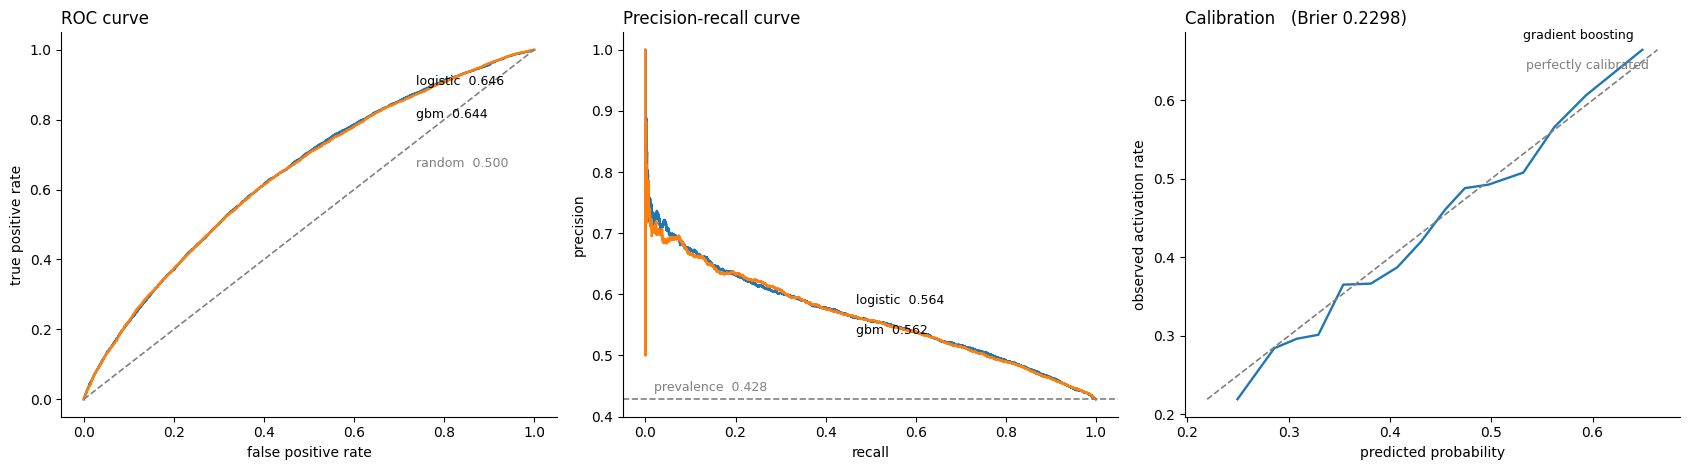

In [0]:
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# --- ROC ---
ax = axes[0]
for nm, p, dy in [("logistic", p_logit, 8), ("gbm", p_gbm, -14)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, linewidth=1.7)
    ax.annotate(f"{nm}  {roc_auc_score(y_test, p):.3f}", (0.72, np.interp(0.72, fpr, tpr)),
                xytext=(6, dy), textcoords="offset points", fontsize=9)
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.2)
ax.annotate("random  0.500", (0.72, 0.72), xytext=(6, -14), textcoords="offset points",
            fontsize=9, color="gray")
ax.set_title("ROC curve", loc="left")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")

# --- Precision-recall ---
ax = axes[1]
for nm, p, dy in [("logistic", p_logit, 8), ("gbm", p_gbm, -14)]:
    pr, rc, _ = precision_recall_curve(y_test, p)
    ax.plot(rc, pr, linewidth=1.7)
    ax.annotate(f"{nm}  {average_precision_score(y_test, p):.3f}",
                (0.45, np.interp(0.45, rc[::-1], pr[::-1])),
                xytext=(6, dy), textcoords="offset points", fontsize=9)
ax.axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1.2)
ax.annotate(f"prevalence  {y_test.mean():.3f}", (0.02, y_test.mean()),
            xytext=(0, 6), textcoords="offset points", fontsize=9, color="gray")
ax.set_title("Precision-recall curve", loc="left")
ax.set_xlabel("recall"); ax.set_ylabel("precision")

# --- Calibration ---
ax = axes[2]
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=15, strategy="quantile")
ax.plot(mean_pred, frac_pos, linewidth=1.7)
ax.annotate(CHOSEN, (mean_pred[-1], frac_pos[-1]), xytext=(-6, 8),
            textcoords="offset points", ha="right", fontsize=9)
lo, hi = min(mean_pred.min(), frac_pos.min()), max(mean_pred.max(), frac_pos.max())
ax.plot([lo, hi], [lo, hi], color="gray", linestyle="--", linewidth=1.2)
ax.annotate("perfectly calibrated", (hi, hi), xytext=(-6, -14),
            textcoords="offset points", ha="right", fontsize=9, color="gray")
ax.set_title(f"Calibration   (Brier {brier_score_loss(y_test, p_test):.4f})", loc="left")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed activation rate")

for a in axes:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**How to read the calibration plot:** each point takes a group of customers with similar predicted probabilities and asks what share of them actually activated.

If the line sits on the gray diagonal, the model's probabilities can be trusted as real probabilities. If it bends below the diagonal, the model is overconfident and every peso figure in section 11 is overstated.


## 11. Where do we cut the list?

The brief is explicit: *"A model that ranks well is not enough; the team must justify where the list is cut and who is left out."*

This table is that justification. We sort everyone by predicted probability, split into ten equal groups, and look at what is inside each.

The column that matters is **`cum_share_of_non_activators`**, read from the bottom. It answers: *if we target the lowest-scoring N% of customers, what share of everyone who fails to activate have we reached?* That is the coverage an intervention buys, and it is what decides the cut point.


In [0]:
lift = pd.DataFrame({"p": p_test, "y": y_test.values})
lift["decile"] = pd.qcut(lift["p"], 10, labels=False, duplicates="drop")

tbl = (lift.groupby("decile")
       .agg(customers=("y", "size"),
            mean_predicted=("p", "mean"),
            observed_rate=("y", "mean"),
            non_activators=("y", lambda s: int((1 - s).sum())))
       .sort_index())                       # decile 0 = lowest probability

tbl["lift_vs_average"]  = tbl["observed_rate"] / y_test.mean()
tbl["cum_customers"]    = tbl["customers"].cumsum()
tbl["cum_share_of_pop"] = tbl["cum_customers"] / len(lift)
tbl["cum_share_of_non_activators"] = tbl["non_activators"].cumsum() / (1 - y_test).sum()

display(tbl.round(4).reset_index())
print("\nDecile 0 = lowest predicted probability (most likely to go dormant).")
print("Read cum_share_of_non_activators downward: it is the coverage of the")
print("target population you buy by extending the list.")

decile,customers,mean_predicted,observed_rate,non_activators,lift_vs_average,cum_customers,cum_share_of_pop,cum_share_of_non_activators
0,2304,0.2594,0.2413,1748,0.5633,2304,0.1,0.1327
1,2304,0.3026,0.2921,1631,0.6818,4608,0.2,0.2566
2,2304,0.3352,0.3225,1561,0.7528,6912,0.3,0.3751
3,2304,0.3742,0.3663,1460,0.8551,9216,0.4,0.486
4,2304,0.4131,0.3984,1386,0.9301,11520,0.5,0.5912
5,2303,0.4486,0.4472,1273,1.044,13823,0.6,0.6879
6,2304,0.4786,0.4887,1178,1.1408,16127,0.7,0.7774
7,2304,0.523,0.5035,1144,1.1752,18431,0.8,0.8642
8,2304,0.5695,0.579,970,1.3515,20735,0.9,0.9379
9,2304,0.6336,0.645,818,1.5055,23039,1.0,1.0



Decile 0 = lowest predicted probability (most likely to go dormant).
Read cum_share_of_non_activators downward: it is the coverage of the
target population you buy by extending the list.


## 12. Three segments and what each one costs

Now the product decision. Three bands by predicted probability:

| Segment | Who they are | Treatment | Why |
| --- | --- | --- | --- |
| **High** | Very likely to activate on their own | Reminder push only | Paying them is pure waste. This is the guardrail. |
| **Mid** | Genuinely uncertain | Push **plus** paid incentive | Most likely to be swung by an offer |
| **Low** | Very unlikely to activate | Push, plus a cheaper test offer | May be unreachable; worth testing, not worth betting on |

### The assumption we are making, stated openly

Putting the expensive offer on the middle band assumes **persuadable customers sit in the middle**. That is a reasonable prior — the top would have converted anyway, the bottom may be unreachable — but it is **a hypothesis, not a finding**. This data has no experiment in it, so uplift cannot be measured.

The PRD must include a holdout group so the next cycle can test it. Say this out loud in the pitch; judges reward the team that knows the limits of its own analysis.


In [0]:
# Cut points - tune these against the decile table above
CUT_LOW, CUT_HIGH = 0.30, 0.60

# ---- PLACEHOLDER ECONOMICS - replace with the team's agreed numbers ----------
COST_PUSH         = 0.20     # MXN per push notification
COST_OFFER        = 120.00   # MXN per redeemed incentive
OFFER_TAKE_RATE   = 0.35     # share of targeted customers who redeem (so who cost money)
VALUE_ACTIVATION  = 850.00   # MXN contribution of one activated customer

# Assumed incremental activation added by the treatment, in percentage points.
# THIS IS THE HYPOTHESIS, NOT A MEASUREMENT.
ASSUMED_UPLIFT_PP = {"low": 0.02, "mid": 0.05, "high": 0.00}
CUT_LOW, CUT_HIGH = 0.40, 0.55
GETS_OFFER = {"low": False, "mid": True, "high": False}
# -----------------------------------------------------------------------------

seg = pd.DataFrame({"p": p_test, "y": y_test.values})
seg["segment"] = pd.cut(seg["p"], [-0.01, CUT_LOW, CUT_HIGH, 1.01],
                        labels=["low", "mid", "high"])

s = (seg.groupby("segment", observed=True)
     .agg(customers=("y", "size"), mean_predicted=("p", "mean"), observed_rate=("y", "mean"))
     .reset_index())
s["share_of_population"] = s["customers"] / len(seg)

# --- scale to the real inflow ---
real_completers_per_day = REAL_DAILY_SIGNUPS * completion_rate
s["customers_per_day_real"] = s["share_of_population"] * real_completers_per_day
s["uplift_pp"] = s["segment"].astype(str).map(ASSUMED_UPLIFT_PP)
s["gets_offer"] = s["segment"].astype(str).map(GETS_OFFER)
s["incremental_activations_per_day"] = s["customers_per_day_real"] * s["uplift_pp"]
s["cost_per_day"] = (
    s["customers_per_day_real"] * COST_PUSH
    + s["gets_offer"] * s["customers_per_day_real"] * OFFER_TAKE_RATE * COST_OFFER)
s["cost_per_incremental_activation"] = (
    s["cost_per_day"] / s["incremental_activations_per_day"].replace(0, np.nan))
s["net_value_per_day"] = (
    s["incremental_activations_per_day"] * VALUE_ACTIVATION - s["cost_per_day"])
s["north_star_pp_gained"] = s["incremental_activations_per_day"] / REAL_DAILY_SIGNUPS * 100

print("=" * 78)
print(f"SCALE: REAL INFLOW - {REAL_DAILY_SIGNUPS:,} signups/day, "
      f"{real_completers_per_day:,.0f} completers/day")
print(f"       (sample is {SAMPLE_DAILY:,.0f}/day; scale ratio {SCALE_RATIO:.2f}x)")
print("=" * 78)

display(s.round(4))

print(f"\nNorth Star : {rate_all:.2%}  ->  {rate_all + s['north_star_pp_gained'].sum()/100:.2%}"
      f"   (+{s['north_star_pp_gained'].sum():.2f} pp)")
print(f"Net value  : MXN {s['net_value_per_day'].sum():,.0f} per day")
print(f"Cost guard : MXN {s['cost_per_day'].sum() / s['incremental_activations_per_day'].sum():,.0f}"
      f" per incremental activation")
print(f"\nHigh segment excluded from paid incentives: "
      f"MXN {s.loc[s['segment'].astype(str)=='high', 'customers_per_day_real'].sum() * OFFER_TAKE_RATE * COST_OFFER:,.0f}"
      f"/day of spend avoided. That is the guardrail, quantified.")

SCALE: REAL INFLOW - 12,000 signups/day, 5,317 completers/day
       (sample is 1,436/day; scale ratio 8.35x)


segment,customers,mean_predicted,observed_rate,share_of_population,customers_per_day_real,uplift_pp,gets_offer,incremental_activations_per_day,cost_per_day,cost_per_incremental_activation,net_value_per_day,north_star_pp_gained
low,9516,0.3204,0.3078,0.413,2195.9428,0.02,false,43.9189,439.1886,10.0,36891.8392,0.366
mid,9120,0.4699,0.4648,0.3959,2104.5606,0.05,true,105.228,88812.4562,844.0,631.3682,0.8769
high,4403,0.6041,0.6137,0.1911,1016.0505,0.0,false,0.0,203.2101,null,-203.2101,0.0



North Star : 19.24%  ->  20.48%   (+1.24 pp)
Net value  : MXN 37,320 per day
Cost guard : MXN 600 per incremental activation

High segment excluded from paid incentives: MXN 42,674/day of spend avoided. That is the guardrail, quantified.


## 13. What did the model actually learn?

Two views.

**Permutation importance** shuffles one column at a time and measures how much PR-AUC drops — the bigger the drop, the more the model relied on it.

**Logistic coefficients** give direction: positive pushes toward activation, negative away from it.


In [0]:
from sklearn.inspection import permutation_importance

sample_idx = X_test.sample(min(20_000, len(X_test)), random_state=RANDOM_STATE).index

imp = permutation_importance(
    model, X_test.loc[sample_idx], y_test.loc[sample_idx],
    scoring="average_precision", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)

display(pd.DataFrame({"feature": FEATURES, "pr_auc_drop_when_shuffled": imp.importances_mean})
        .sort_values("pr_auc_drop_when_shuffled", ascending=False)
        .head(20).round(5).reset_index(drop=True))

feature,pr_auc_drop_when_shuffled
referred_by_customer,0.08418
acquisition_channel,0.03488
prev_bank_relationship,0.01705
selfie_attempts,0.01694
log_ms_step_3,0.00524
age,0.00497
wall_clock_seconds,7.4E-4
total_ms_step_7,6.6E-4
log_ms_step_4,4.4E-4
total_ms_step_6,3.6E-4


In [0]:
onehot = logit.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
coef_names = NUMERIC + BOOLEAN + list(onehot.get_feature_names_out(CATEGORICAL))

coefs = (pd.DataFrame({"feature": coef_names, "coefficient": logit.named_steps["clf"].coef_[0]})
         .assign(abs_coef=lambda d: d["coefficient"].abs())
         .sort_values("abs_coef", ascending=False)
         .drop(columns="abs_coef"))

display(coefs.head(20).round(4).reset_index(drop=True))
print("\nPositive = pushes toward activating. Negative = pushes away.")
print("Coefficients are on standardised inputs, so they are comparable to each other.")

feature,coefficient
acquisition_channel_paid_social,-0.4369
acquisition_channel_organic,0.3845
referred_by_customer,0.3185
acquisition_channel_affiliate,-0.234
prev_bank_relationship,0.1703
age,0.1044
device_os_ios,-0.0979
state_Puebla,-0.0965
acquisition_channel_referral,0.0932
n_retry_rows,-0.0928



Positive = pushes toward activating. Negative = pushes away.
Coefficients are on standardised inputs, so they are comparable to each other.


## 14. Score everyone and save


In [0]:
scored = pdf[["customer_id", "signup_ts"]].copy()
scored["p_activate_30d"] = model.predict_proba(pdf[FEATURES])[:, 1]
scored["segment"] = pd.cut(scored["p_activate_30d"], [-0.01, CUT_LOW, CUT_HIGH, 1.01],
                           labels=["low", "mid", "high"]).astype(str)
scored["model_version"] = "model_b_v1"
scored["scored_at"] = pd.Timestamp.utcnow()

print(scored["segment"].value_counts().to_string())
print(f"\n{len(scored):,} customers scored")
display(scored.head(10))

low     46855
mid     45745
high    22592

115,192 customers scored


customer_id,signup_ts,p_activate_30d,segment,model_version,scored_at
1000133,2026-02-06T23:29:24Z,0.2708167487399021,low,model_b_v1,2026-09-02T17:44:37.736502Z
1000150,2026-05-08T12:35:52Z,0.581187779675985,high,model_b_v1,2026-09-02T17:44:37.736502Z
1000152,2026-02-25T06:40:43Z,0.49874053725538914,mid,model_b_v1,2026-09-02T17:44:37.736502Z
1000216,2026-07-24T07:15:46Z,0.47370249548439336,mid,model_b_v1,2026-09-02T17:44:37.736502Z
1000249,2026-02-15T02:50:38Z,0.5905943402109055,high,model_b_v1,2026-09-02T17:44:37.736502Z
1000282,2026-06-28T02:16:06Z,0.42834399942478074,mid,model_b_v1,2026-09-02T17:44:37.736502Z
1000375,2026-05-15T23:08:32Z,0.6349128934792672,high,model_b_v1,2026-09-02T17:44:37.736502Z
1000393,2026-06-06T09:55:11Z,0.4419818540636892,mid,model_b_v1,2026-09-02T17:44:37.736502Z
1000517,2026-03-08T13:49:17Z,0.652454344325651,high,model_b_v1,2026-09-02T17:44:37.736502Z
1000651,2026-02-15T18:37:09Z,0.43144671951373903,mid,model_b_v1,2026-09-02T17:44:37.736502Z


## 15. Summary for the repo

### For `docs/decision-log.md`

**Population.** Model B trains only on customers with `completed_onboarding = true` (115,192 of 260,000). Activation is only evaluated among completers, so training on all signups would produce a model of funnel completion rather than activation. `completed_onboarding` and `steps_completed` are used as the population filter and excluded as features; inside the population they are constants.

**Leakage.** Verified empirically, not assumed. `days_to_first_transaction` and `first_transaction_ts` are null if and only if `activated_30d` is false — 0 violations across 260,000 rows in both directions. Both dropped before modelling. `completed_onboarding` and `steps_completed == 7` confirmed identical, 0 discrepancies.

**Nulls.** Contrary to the dataset README, `customers` and `onboarding_events` contain no nulls at all. The only nulls in the dataset are the 209,976 rows in the two leakage columns, which are structural rather than missing. No imputation decision was required.

**Event aggregation.** `onboarding_events` is aggregated to `customer_id` grain before joining to `customers`. Time per step uses `SUM(ms_on_step)` across attempts, because `ms_on_step` is per attempt and `selfie_liveness` is the only step with retries; MAX or AVG would understate the customers who struggled most.

**Censoring.** No right-censoring found. Monthly activation is flat across the window (19.37% first month, 18.96% last), so no cohorts were excluded.

**Validation split.** Temporal, by `signup_ts`, last 20% held out. A random split would let the model see the period it is tested on.

**Stated limitation.** The model estimates propensity, not uplift. With no treatment variation in the data, incremental effect of the intervention is not estimable. Assigning the paid incentive to the middle probability band is a documented hypothesis, and the rollout must include a holdout to test it.

### For `docs/uso-de-ia.md`

*Claude (Opus) — asked to design and write the Model B pipeline (30-day activation propensity among onboarding completers), including leakage verification, event aggregation to customer grain, temporal validation split, ROC-AUC / PR-AUC / calibration reporting, and probability-based segmentation with parametric cost sizing. Data profiling figures were validated directly against the Parquet files via Databricks SQL before the notebook was written. Output reviewed and executed by the BA team.*


In [0]:
if WRITE_TABLES:
    spark.createDataFrame(scored).write.mode("overwrite") \
        .saveAsTable(f"{OUTPUT_SCHEMA}.model_b_activation_scores")
    feat_sdf.write.mode("overwrite") \
        .saveAsTable(f"{OUTPUT_SCHEMA}.customer_wide_completers")
    print(f"written to {OUTPUT_SCHEMA}")
else:
    print("WRITE_TABLES is False - nothing saved. Set it to True when ready.")

WRITE_TABLES is False - nothing saved. Set it to True when ready.


In [0]:
# =============================================================================
# EXTRA CELLS — charts and profile definition
#
# Paste these as new cells at the end of the notebook.
# Requires: p_test, y_test, p_logit, p_gbm, model, pdf, FEATURES  (sections 7-10)
# Nothing here writes to disk or to any table.
# =============================================================================

In [0]:

# --- CELL 1 --------------------------------------------------------------
# Score everyone, then find the tercile boundaries from the actual data.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

p_all = model.predict_proba(pdf[FEATURES])[:, 1]

q33, q67 = np.quantile(p_all, [1/3, 2/3])

print(f"customers scored        : {len(p_all):,}")
print(f"probability range       : {p_all.min():.3f}  to  {p_all.max():.3f}")
print(f"median                  : {np.median(p_all):.3f}")
print()
print(f"tercile cut points (computed from the data, not chosen by hand)")
print(f"  lower third  : p <  {q33:.3f}")
print(f"  middle third : {q33:.3f} <= p < {q67:.3f}")
print(f"  upper third  : p >= {q67:.3f}")

customers scored        : 115,192
probability range       : 0.165  to  0.752
median                  : 0.432

tercile cut points (computed from the data, not chosen by hand)
  lower third  : p <  0.369
  middle third : 0.369 <= p < 0.483
  upper third  : p >= 0.483


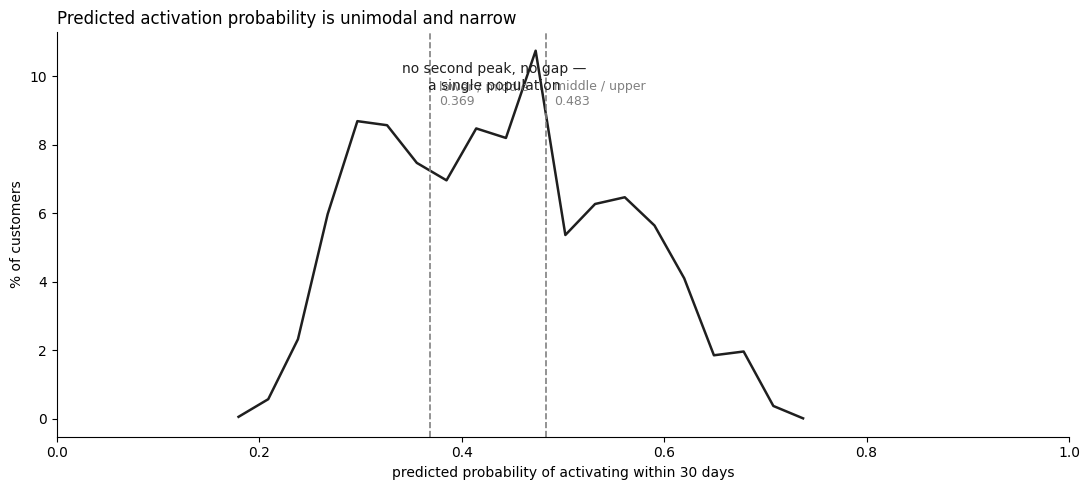

Note the x-axis runs 0 to 1 on purpose. The model never assigns anyone
a probability near 0 or near 1 — the whole population sits in a narrow band.


In [0]:
# --- CELL 2 --------------------------------------------------------------
# Distribution of predicted probability.
# This is the chart that answers "are there natural groups?"

fig, ax = plt.subplots(figsize=(11, 5))

counts, edges = np.histogram(p_all, bins=20)
centres = (edges[:-1] + edges[1:]) / 2
share = counts / counts.sum() * 100

ax.plot(centres, share, linewidth=1.8, color="#1f1f1f")

for q, label in [(q33, "lower / middle"), (q67, "middle / upper")]:
    ax.axvline(q, color="gray", linestyle="--", linewidth=1.2)
    ax.annotate(f"{label}\n{q:.3f}", (q, share.max() * 0.92),
                xytext=(6, 0), textcoords="offset points",
                fontsize=9, color="gray", va="top")

ax.annotate("no second peak, no gap —\na single population",
            (np.median(p_all), share.max()),
            xytext=(0, -28), textcoords="offset points",
            fontsize=10, ha="center", color="#1f1f1f")

ax.set_xlim(0, 1)
ax.set_xlabel("predicted probability of activating within 30 days")
ax.set_ylabel("% of customers")
ax.set_title("Predicted activation probability is unimodal and narrow", loc="left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("Note the x-axis runs 0 to 1 on purpose. The model never assigns anyone")
print("a probability near 0 or near 1 — the whole population sits in a narrow band.")

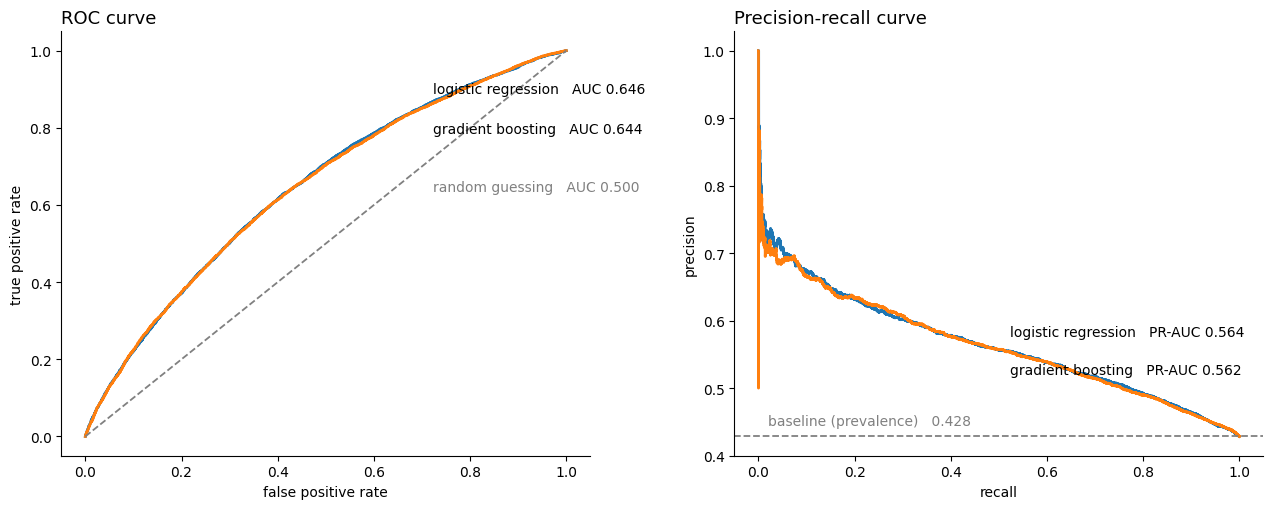

PR-AUC floor is the share of positives in the test set, not 0.5.
Anything above 0.428 is real signal.


In [0]:

# --- CELL 3 --------------------------------------------------------------
# ROC and precision-recall, presentation version.
# Same numbers as section 10, larger and cleaner for the deck.

from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# --- ROC ---
ax = axes[0]
for nm, p, dy in [("logistic regression", p_logit, 10), ("gradient boosting", p_gbm, -18)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, linewidth=2.0)
    ax.annotate(f"{nm}   AUC {roc_auc_score(y_test, p):.3f}",
                (0.70, np.interp(0.70, fpr, tpr)),
                xytext=(8, dy), textcoords="offset points", fontsize=10)

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.3)
ax.annotate("random guessing   AUC 0.500", (0.70, 0.70),
            xytext=(8, -18), textcoords="offset points", fontsize=10, color="gray")

ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curve", loc="left", fontsize=13)

# --- Precision-recall ---
ax = axes[1]
for nm, p, dy in [("logistic regression", p_logit, 10), ("gradient boosting", p_gbm, -18)]:
    pr, rc, _ = precision_recall_curve(y_test, p)
    ax.plot(rc, pr, linewidth=2.0)
    ax.annotate(f"{nm}   PR-AUC {average_precision_score(y_test, p):.3f}",
                (0.50, np.interp(0.50, rc[::-1], pr[::-1])),
                xytext=(8, dy), textcoords="offset points", fontsize=10)

base = y_test.mean()
ax.axhline(base, color="gray", linestyle="--", linewidth=1.3)
ax.annotate(f"baseline (prevalence)   {base:.3f}", (0.02, base),
            xytext=(0, 8), textcoords="offset points", fontsize=10, color="gray")

ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision-recall curve", loc="left", fontsize=13)

for a in axes:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("PR-AUC floor is the share of positives in the test set, not 0.5.")
print(f"Anything above {base:.3f} is real signal.")

In [0]:
# --- CELL 4 --------------------------------------------------------------
# The three profiles, described from the data.

seg = pd.DataFrame({"p": p_test, "y": y_test.values})
seg["profile"] = pd.cut(seg["p"], [-0.01, q33, q67, 1.01],
                        labels=["lower third", "middle third", "upper third"])

profiles = (seg.groupby("profile", observed=True)
            .agg(customers=("y", "size"),
                 mean_predicted=("p", "mean"),
                 observed_activation=("y", "mean"))
            .reset_index())
profiles["share_of_population"] = profiles["customers"] / len(seg)
profiles["lift_vs_average"] = profiles["observed_activation"] / seg["y"].mean()

display(profiles.round(4))

print(f"\nOverall activation among completers: {seg['y'].mean():.1%}")
print("The gap between the lower and upper third is the whole value of the model.")

profile,customers,mean_predicted,observed_activation,share_of_population,lift_vs_average
lower third,7819,0.3063,0.2949,0.3394,0.6884
middle third,7614,0.4311,0.4261,0.3305,0.9945
upper third,7606,0.5675,0.568,0.3301,1.3258



Overall activation among completers: 42.8%
The gap between the lower and upper third is the whole value of the model.


In [0]:
# --- CELL 5 --------------------------------------------------------------
# Who is in each profile? Composition by channel and device.
# This is what turns three numbers into three describable customer types.

test_profiled = pdf.loc[y_test.index].copy()
test_profiled["profile"] = seg["profile"].values

for col in ["acquisition_channel", "device_os", "prev_bank_relationship"]:
    comp = (pd.crosstab(test_profiled["profile"], test_profiled[col], normalize="index") * 100)
    print(f"\n--- {col}  (% within each profile) ---")
    print(comp.round(1).to_string())

print("\n\nNumeric averages by profile:")
print(test_profiled.groupby("profile", observed=True)[
    ["age", "selfie_attempts", "n_retry_rows"]].mean().round(2).to_string())


--- acquisition_channel  (% within each profile) ---
acquisition_channel  affiliate  organic  paid_search  paid_social  referral
profile                                                                    
lower third               13.6      5.9         17.9         62.4       0.2
middle third               5.9     52.9         29.9          6.5       4.8
upper third                0.3     36.7          2.9          0.0      60.1

--- device_os  (% within each profile) ---
device_os     android   ios
profile                    
lower third      67.2  32.8
middle third     69.4  30.6
upper third      68.9  31.1

--- prev_bank_relationship  (% within each profile) ---
prev_bank_relationship     0     1
profile                           
lower third             68.5  31.5
middle third            60.1  39.9
upper third             39.4  60.6


Numeric averages by profile:
                age  selfie_attempts  n_retry_rows
profile                                           
lower third   31.

In [0]:
# =============================================================================
# REPLACES CELL 2 of the extra cells.
# Three things: a cleaner 20-bin chart, a diagnostic that explains the bumps,
# and a helper that sizes the segments for whatever cut you choose.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BINS = 20

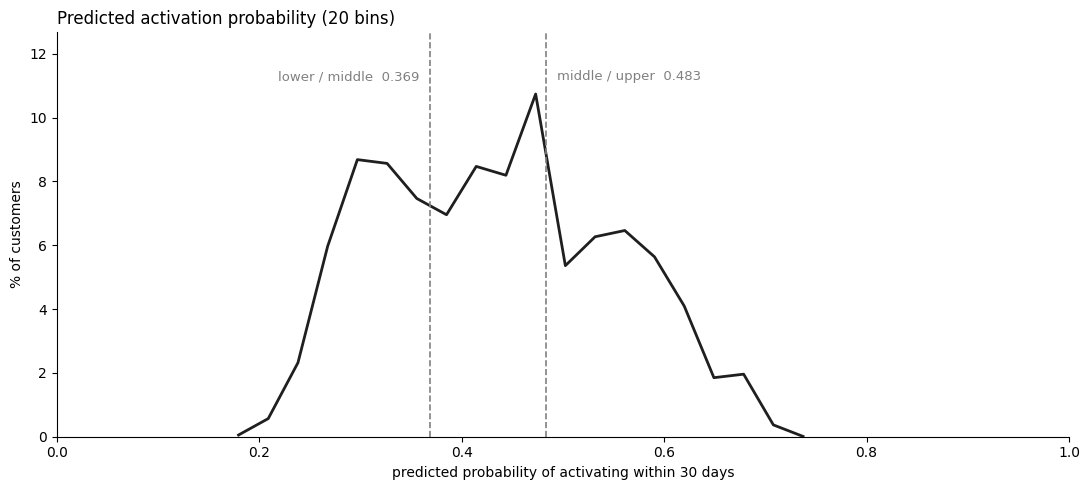

In [0]:
# ---------------------------------------------------------------------------
# 1. The distribution, 20 bins, with the annotations no longer on top of
#    each other.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))

counts, edges = np.histogram(p_all, bins=BINS)
centres = (edges[:-1] + edges[1:]) / 2
share = counts / counts.sum() * 100

ax.plot(centres, share, linewidth=2.0, color="#1f1f1f")

for q, label, side in [(q33, "lower / middle", "right"), (q67, "middle / upper", "left")]:
    ax.axvline(q, color="gray", linestyle="--", linewidth=1.2)
    ax.annotate(f"{label}  {q:.3f}", (q, share.max() * 1.04),
                xytext=(-8 if side == "right" else 8, 0),
                textcoords="offset points",
                fontsize=9.5, color="gray",
                ha="right" if side == "right" else "left")

ax.set_xlim(0, 1)
ax.set_ylim(0, share.max() * 1.18)
ax.set_xlabel("predicted probability of activating within 30 days")
ax.set_ylabel("% of customers")
ax.set_title(f"Predicted activation probability ({BINS} bins)", loc="left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

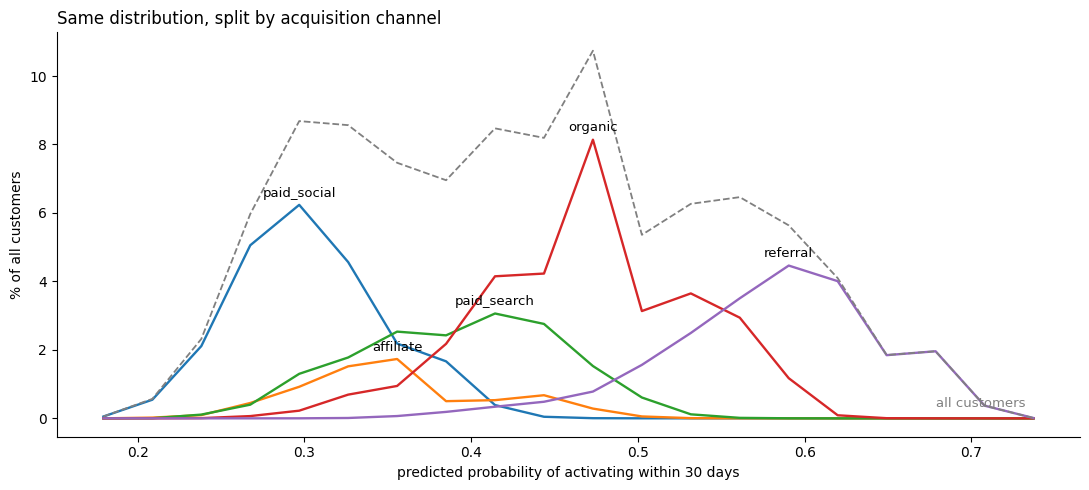

If each channel sits in its own hump, the dips in the combined curve are
gaps between channels - not natural customer segments. Say it that way.


In [0]:
# ---------------------------------------------------------------------------
# 2. DIAGNOSTIC: are the bumps just the acquisition channels?
#    Same histogram, one line per channel. If each channel forms its own
#    cluster, the "valleys" are gaps between channels, not customer segments.
# ---------------------------------------------------------------------------
chan_all = pdf["acquisition_channel"].values

fig, ax = plt.subplots(figsize=(11, 5))
common_edges = np.linspace(p_all.min(), p_all.max(), BINS + 1)
centres = (common_edges[:-1] + common_edges[1:]) / 2

order = (pd.Series(p_all).groupby(chan_all).mean().sort_values().index)

for ch in order:
    c, _ = np.histogram(p_all[chan_all == ch], bins=common_edges)
    y = c / len(p_all) * 100          # share of the WHOLE population
    ax.plot(centres, y, linewidth=1.7)
    peak = centres[int(np.argmax(y))]
    ax.annotate(ch, (peak, y.max()), xytext=(0, 6), textcoords="offset points",
                fontsize=9.5, ha="center")

# total, as the reference series
c_tot, _ = np.histogram(p_all, bins=common_edges)
ax.plot(centres, c_tot / len(p_all) * 100, color="gray", linestyle="--", linewidth=1.3)
ax.annotate("all customers", (centres[-1], (c_tot / len(p_all) * 100)[-1]),
            xytext=(-6, 8), textcoords="offset points", ha="right",
            fontsize=9.5, color="gray")

ax.set_xlabel("predicted probability of activating within 30 days")
ax.set_ylabel("% of all customers")
ax.set_title("Same distribution, split by acquisition channel", loc="left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("If each channel sits in its own hump, the dips in the combined curve are")
print("gaps between channels - not natural customer segments. Say it that way.")

In [0]:
# ---------------------------------------------------------------------------
# 3. Find the actual low point near 0.50, rather than eyeballing it.
# ---------------------------------------------------------------------------
fine_counts, fine_edges = np.histogram(p_all, bins=60)
fine_centres = (fine_edges[:-1] + fine_edges[1:]) / 2

window = (fine_centres > 0.46) & (fine_centres < 0.56)
valley = fine_centres[window][int(np.argmin(fine_counts[window]))]

print(f"\nlowest-density point between 0.46 and 0.56 : {valley:.4f}")
print(f"equal-thirds cut for comparison            : {q67:.4f}")


lowest-density point between 0.46 and 0.56 : 0.5122
equal-thirds cut for comparison            : 0.4828


In [0]:
# ---------------------------------------------------------------------------
# 4. Size the segments for any candidate cut, so the trade-off is visible
#    before you commit to it.
# ---------------------------------------------------------------------------
def size_cuts(low, high, label):
    seg = pd.cut(p_test, [-0.01, low, high, 1.01], labels=["lower", "middle", "upper"])
    out = (pd.DataFrame({"segment": seg, "y": y_test.values})
           .groupby("segment", observed=True)
           .agg(customers=("y", "size"), activation=("y", "mean")))
    out["share"] = out["customers"] / len(p_test)
    print(f"\n--- {label}  (cuts {low:.3f} / {high:.3f}) ---")
    print(out.assign(share=lambda d: (d["share"] * 100).round(1),
                     activation=lambda d: (d["activation"] * 100).round(1)).to_string())

size_cuts(q33, q67,    "equal thirds")
size_cuts(q33, valley, "upper cut moved to the valley")


--- equal thirds  (cuts 0.369 / 0.483) ---
         customers  activation  share
segment                              
lower         7819        29.5   33.9
middle        7614        42.6   33.0
upper         7606        56.8   33.0

--- upper cut moved to the valley  (cuts 0.369 / 0.512) ---
         customers  activation  share
segment                              
lower         7819        29.5   33.9
middle        8958        43.6   38.9
upper         6262        58.4   27.2


In [0]:
CUT_LOW, CUT_HIGH = 0.369, 0.500

seg = pd.cut(p_test, [-0.01, CUT_LOW, CUT_HIGH, 1.01],
             labels=["lower", "middle", "upper"])
prof = (pd.DataFrame({"segment": seg, "y": y_test.values})
        .groupby("segment", observed=True)
        .agg(customers=("y", "size"), activation=("y", "mean")))
prof["share_%"] = (prof["customers"] / len(p_test) * 100).round(1)
prof["activation_%"] = (prof["activation"] * 100).round(1)
print(prof[["customers", "share_%", "activation_%"]].to_string())

tp = pdf.loc[y_test.index].copy()
tp["segment"] = np.asarray(seg)
for col in ["acquisition_channel", "prev_bank_relationship"]:
    print(f"\n--- {col} (% dentro de cada perfil) ---")
    print((pd.crosstab(tp["segment"], tp[col], normalize="index")*100).round(1).to_string())
print("\n" + tp.groupby("segment", observed=True)[["age","selfie_attempts"]].mean().round(2).to_string())

         customers  share_%  activation_%
segment                                  
lower         7811     33.9          29.5
middle        8448     36.7          43.2
upper         6780     29.4          57.7

--- acquisition_channel (% dentro de cada perfil) ---
acquisition_channel  affiliate  organic  paid_search  paid_social  referral
segment                                                                    
lower                     13.6      5.9         17.9         62.4       0.2
middle                     5.6     54.0         28.4          5.9       6.1
upper                      0.0     33.3          1.5          0.0      65.2

--- prev_bank_relationship (% dentro de cada perfil) ---
prev_bank_relationship     0     1
segment                           
lower                   68.5  31.5
middle                  59.0  41.0
upper                   38.2  61.8

           age  selfie_attempts
segment                        
lower    31.63             1.58
middle   33.62           

ROC-AUC detecting non-activators : 0.6441   (same as before, by construction)
PR-AUC  detecting non-activators : 0.6922
  floor for this direction       : 0.5716


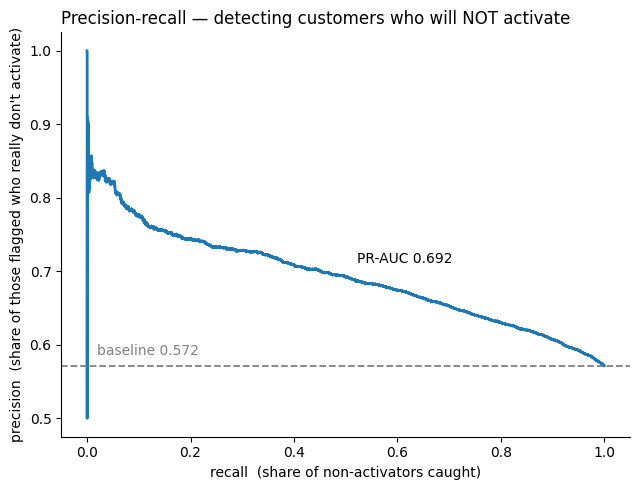

In [0]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt

y_neg = 1 - y_test          # 1 = NO activó
p_neg = 1 - p_test          # probabilidad de NO activar

print(f"ROC-AUC detecting non-activators : {roc_auc_score(y_neg, p_neg):.4f}   (same as before, by construction)")
print(f"PR-AUC  detecting non-activators : {average_precision_score(y_neg, p_neg):.4f}")
print(f"  floor for this direction       : {y_neg.mean():.4f}")

fig, ax = plt.subplots(figsize=(6.5, 5))
pr, rc, _ = precision_recall_curve(y_neg, p_neg)
ax.plot(rc, pr, linewidth=2.0)
ax.annotate(f"PR-AUC {average_precision_score(y_neg, p_neg):.3f}",
            (0.5, np.interp(0.5, rc[::-1], pr[::-1])),
            xytext=(8, 10), textcoords="offset points", fontsize=10)
ax.axhline(y_neg.mean(), color="gray", linestyle="--", linewidth=1.3)
ax.annotate(f"baseline {y_neg.mean():.3f}", (0.02, y_neg.mean()),
            xytext=(0, 8), textcoords="offset points", fontsize=10, color="gray")
ax.set_xlabel("recall  (share of non-activators caught)")
ax.set_ylabel("precision  (share of those flagged who really don't activate)")
ax.set_title("Precision-recall — detecting customers who will NOT activate", loc="left")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

Activation model is done. Quick summary:

**What it does**

Gives every customer who opened an account a probability (0 to 1) of making a first transaction within 30 days. Trained on the 115,192 people who completed onboarding.

**How well it works**

ROC-AUC 0.644, PR-AUC 0.563 (baseline 0.428). It's a modest model — most of what it knows is the acquisition channel. Good enough to rank customers, not to make precise individual calls.

**Three groups**

| Group | Probability | Share | Actually activate |
| --- | --- | --- | --- |
| High | ≥ 0.500 | 28% | 58.4% |
| Medium | 0.369 – 0.500 | 39% | 43.1% |
| Low | < 0.369 | 33% | 29.5% |

The high group is 67% referrals. The low group is 63% paid social. Zero overlap between those two channels at the extremes.

**Proposal**

* High → no contact, they convert on their own
* Medium → reminder push
* Low → push plus a promotion

We'd run this as an A/B with a control group spread across all three, so we can actually measure whether the push and the promotion do anything.

HTML walkthrough and the notebook are attached — the HTML explains the whole thing without needing to read code.
